In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = '/content/drive/MyDrive/seminar/'

df = pd.read_csv(path + 'features.csv')
print(f"features.csv shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few columns sample:")
print(df.head(2))

if 'readmitted_30d' in df.columns:
    print(f"\nTarget column found! Readmission rate: {df['readmitted_30d'].mean():.2%}")
else:
    print(f"\nNo readmitted_30d column. Columns are: {df.columns.tolist()}")

features.csv shape: (83108, 29)
Columns: ['Unnamed: 0', 'subject_id', 'hadm_id', 'target', 'age', 'is_male', 'los_days', 'disch_home', 'insurance_gov', 'living_alone', 'prior_visits_1yr', 'total_diagnoses', 'hist_heart_failure', 'hist_copd', 'hist_renal_failure', 'acute_dialysis', 'was_ventilated', 'hr_mean', 'hr_std', 'bp_mean', 'spo2_min', 'gcs_motor_min', 'braden_score_est', 'creat_max', 'sodium_max', 'hemoglobin_min', 'glucose_mean', 'wbc_last', 'total_urine_24h']

First few columns sample:
   Unnamed: 0  subject_id   hadm_id  target  age  is_male  los_days  \
0           0    10002495  24982426       0   81        1       5.0   
1           1    10002930  25696644       0   51        0       1.0   

   disch_home  insurance_gov  living_alone  ...    bp_mean  spo2_min  \
0           0              1             0  ...  75.695652      91.0   
1           0              1             1  ...  75.652174      95.0   

   gcs_motor_min  braden_score_est  creat_max  sodium_max  hemoglobin

In [3]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/seminar/'
df = pd.read_csv(path + 'features.csv')

df = df.rename(columns={'target': 'readmitted_30d'})
df = df.drop(columns=['Unnamed: 0'])

print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique patients: {df['subject_id'].nunique():,}")
print(f"Readmission rate: {df['readmitted_30d'].mean():.2%}")
print(f"Missing values :")
missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].to_string())
print(f"\nClass balance:")
print(df['readmitted_30d'].value_counts())
df.to_csv(path + 'mimic_modeling_ready.csv', index=False)


Shape          : 83,108 rows × 28 columns
Unique patients: 58,280
Readmission rate: 13.34%
Missing values :
wbc_last            0.055530
hemoglobin_min      0.055518
glucose_mean        0.051186
creat_max           0.048696
sodium_max          0.047926
total_urine_24h     0.047841
bp_mean             0.015859
braden_score_est    0.012502
gcs_motor_min       0.002984
spo2_min            0.002346
hr_std              0.001733
hr_mean             0.001251
los_days            0.000084

Class balance:
readmitted_30d
0    72025
1    11083
Name: count, dtype: int64


  Shape: (83108, 28) | Readmission: 13.34%
  Features : 25
  Patients : 58,280
  Train : 66,609 stays | 13.41% positive
  Test  : 16,499 stays  | 13.06% positive

───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
  AUC             0.7538   [0.7418, 0.7662]
  PR_AUC          0.3673   [0.3462, 0.3903]
  F1              0.3948   [0.3802, 0.4096]
  Brier           0.1925   [0.1899, 0.1950]
  Sensitivity     0.6565   [0.6362, 0.6758]
  Specificity     0.7493   [0.7423, 0.7561]
  Best C: 10000.0000 | Non-zero features: 25/25

───────────────────────────────────────────────────────
  LASSO (L1)
───────────────────────────────────────────────────────
  AUC             0.7538   [0.7418, 0.7662]
  PR_AUC          0.3673   [0.3462, 0.3902]
  F1              0.3948   [0.3802, 0.4097]
  Brier           0.1925   [0.1900, 0.1950]
  Sensitivity     0.6565   [0.6362, 0.6758]
  Specificity     0.7494   [0.7423, 0.7561]
 

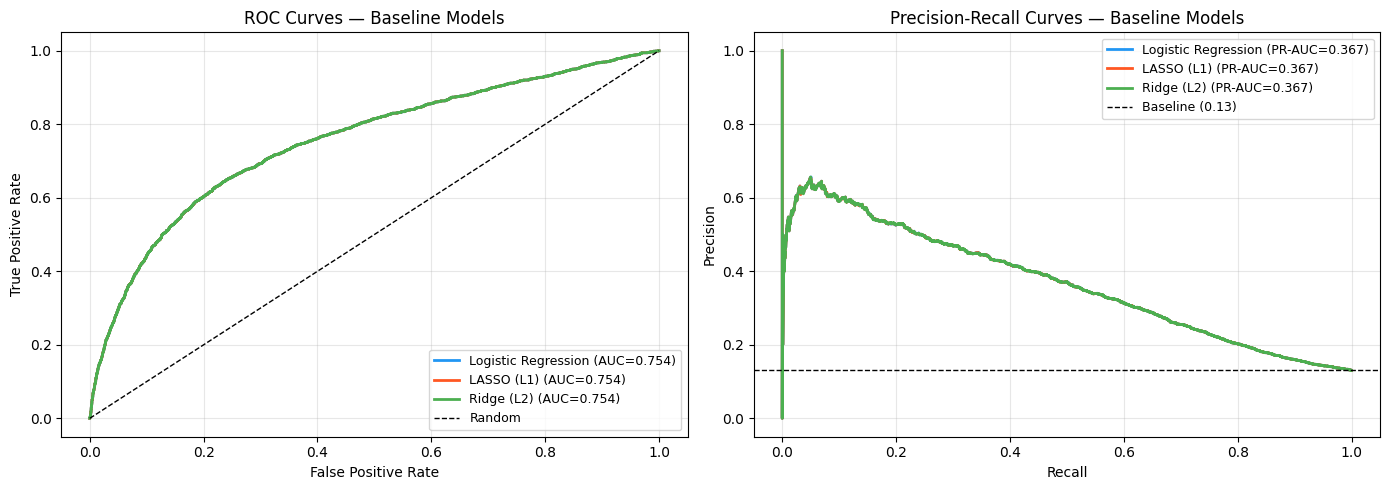

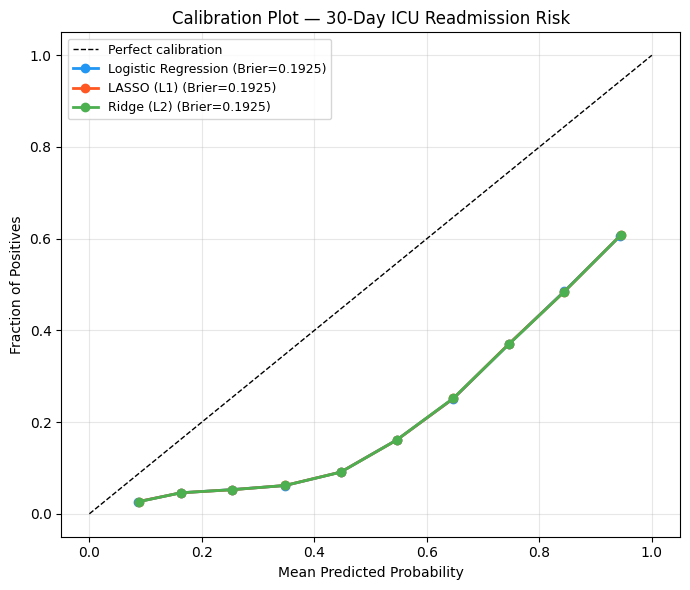

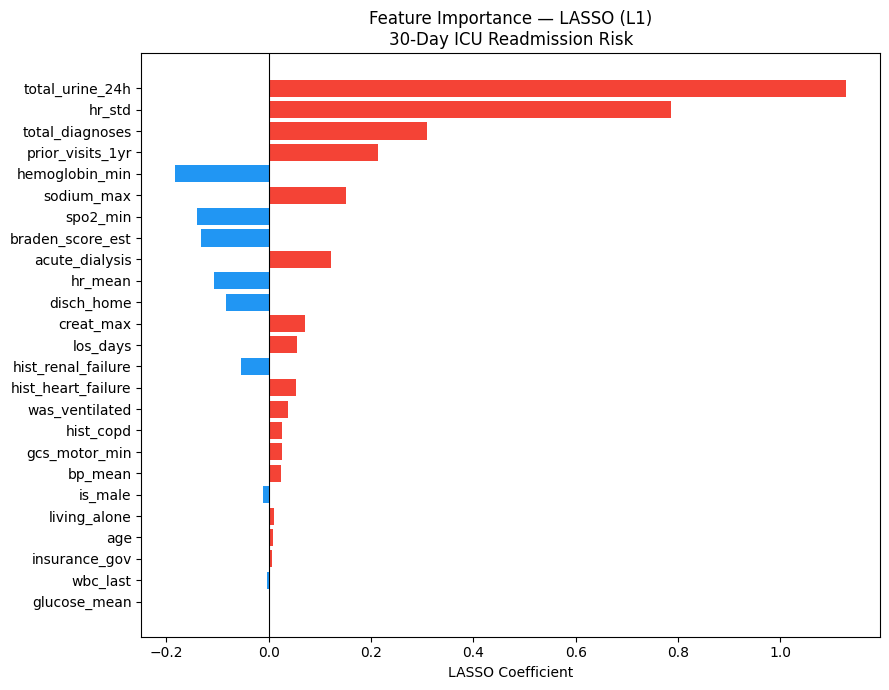

Model                        AUC   PR-AUC     F1   Brier   Sens   Spec
Logistic Regression        0.754    0.367  0.395  0.1925  0.656  0.749
LASSO (L1)                 0.754    0.367  0.395  0.1925  0.656  0.749
Ridge (L2)                 0.754    0.367  0.395  0.1925  0.656  0.750


In [4]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    brier_score_loss, confusion_matrix, roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve

PATH        = '/content/drive/MyDrive/seminar/'
INPUT_PATH  = PATH + 'mimic_modeling_ready.csv'
SEED        = 42
N_SPLITS    = 5
N_BOOT      = 1000

os.makedirs(PATH, exist_ok=True)

df = pd.read_csv(INPUT_PATH)
print(f"  Shape: {df.shape} | Readmission: {df['readmitted_30d'].mean():.2%}")

TARGET    = "readmitted_30d"
GROUP_COL = "subject_id"

FEATURE_COLS = [
    'age', 'is_male', 'los_days', 'disch_home', 'insurance_gov',
    'living_alone', 'prior_visits_1yr', 'total_diagnoses',
    'hist_heart_failure', 'hist_copd', 'hist_renal_failure',
    'acute_dialysis', 'was_ventilated', 'hr_mean', 'hr_std',
    'bp_mean', 'spo2_min', 'gcs_motor_min', 'braden_score_est',
    'creat_max', 'sodium_max', 'hemoglobin_min', 'glucose_mean',
    'wbc_last', 'total_urine_24h'
]

X      = df[FEATURE_COLS].copy()
y      = df[TARGET].copy()
groups = df[GROUP_COL].copy()

print(f"  Features : {X.shape[1]}")
print(f"  Patients : {groups.nunique():,}")


sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
for train_idx, test_idx in sgkf.split(X, y, groups=groups):
    pass

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
assert len(overlap) == 0, "Patient leakage!"

print(f"  Train : {len(X_train):,} stays | {y_train.mean():.2%} positive")
print(f"  Test  : {len(X_test):,} stays  | {y_test.mean():.2%} positive")


mice = IterativeImputer(max_iter=10, random_state=SEED)
X_train_imp = mice.fit_transform(X_train)
X_test_imp  = mice.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

joblib.dump(mice,   PATH + 'mice_imputer_phase2.pkl')
joblib.dump(scaler, PATH + 'standard_scaler.pkl')

np.save(PATH + 'train_idx.npy', train_idx)
np.save(PATH + 'test_idx.npy',  test_idx)

def evaluate(name, y_true, y_prob, threshold=0.5):
    rng    = np.random.default_rng(SEED)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        "AUC"        : roc_auc_score(y_true, y_prob),
        "PR_AUC"     : average_precision_score(y_true, y_prob),
        "F1"         : f1_score(y_true, y_pred),
        "Brier"      : brier_score_loss(y_true, y_prob),
        "Sensitivity": tp/(tp+fn) if (tp+fn)>0 else 0,
        "Specificity": tn/(tn+fp) if (tn+fp)>0 else 0,
    }

    boot = {k: [] for k in metrics}
    ya   = np.array(y_true)
    n    = len(ya)
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        yb, pb = ya[idx], y_prob[idx]
        yp     = (pb >= threshold).astype(int)
        if len(np.unique(yb)) < 2:
            continue
        tni,fpi,fni,tpi = confusion_matrix(yb,yp).ravel()
        boot["AUC"].append(roc_auc_score(yb, pb))
        boot["PR_AUC"].append(average_precision_score(yb, pb))
        boot["F1"].append(f1_score(yb, yp, zero_division=0))
        boot["Brier"].append(brier_score_loss(yb, pb))
        boot["Sensitivity"].append(tpi/(tpi+fni) if (tpi+fni)>0 else 0)
        boot["Specificity"].append(tni/(tni+fpi) if (tni+fpi)>0 else 0)

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    for k, v in metrics.items():
        lo = np.percentile(boot[k], 2.5)
        hi = np.percentile(boot[k], 97.5)
        print(f"  {k:<15} {v:.4f}   [{lo:.4f}, {hi:.4f}]")

    return metrics

all_probs   = {}
all_metrics = {}

# MODEL 1: Logistic Regression 

lr = LogisticRegression(
    penalty      = None,
    solver       = 'lbfgs',
    max_iter     = 1000,
    class_weight = 'balanced',
    random_state = SEED
)
lr.fit(X_train_sc, y_train)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

m = evaluate("Logistic Regression", y_test, y_prob_lr)
all_probs["Logistic Regression"]   = y_prob_lr
all_metrics["Logistic Regression"] = m
joblib.dump(lr, PATH + 'model_lr.pkl')

# MODEL 2: LASSO (L1)

lasso = LogisticRegressionCV(
    Cs           = 10,
    cv           = 5,
    penalty      = 'l1',
    solver       = 'saga',
    max_iter     = 2000,
    scoring      = 'roc_auc',
    class_weight = 'balanced',
    random_state = SEED,
    n_jobs       = -1
)
lasso.fit(X_train_sc, y_train)
y_prob_lasso = lasso.predict_proba(X_test_sc)[:, 1]

n_nonzero = int(np.sum(lasso.coef_[0] != 0))
print(f"  Best C: {lasso.C_[0]:.4f} | Non-zero features: {n_nonzero}/{X_train_sc.shape[1]}")

m = evaluate("LASSO (L1)", y_test, y_prob_lasso)
all_probs["LASSO (L1)"]   = y_prob_lasso
all_metrics["LASSO (L1)"] = m
joblib.dump(lasso, PATH + 'model_lasso.pkl')

# MODEL 3: Ridge (L2)

ridge = LogisticRegressionCV(
    Cs           = 10,
    cv           = 5,
    penalty      = 'l2',
    solver       = 'lbfgs',
    max_iter     = 1000,
    scoring      = 'roc_auc',
    class_weight = 'balanced',
    random_state = SEED,
    n_jobs       = -1
)
ridge.fit(X_train_sc, y_train)
y_prob_ridge = ridge.predict_proba(X_test_sc)[:, 1]

print(f"  Best C: {ridge.C_[0]:.4f}")

m = evaluate("Ridge (L2)", y_test, y_prob_ridge)
all_probs["Ridge (L2)"]   = y_prob_ridge
all_metrics["Ridge (L2)"] = m
joblib.dump(ridge, PATH + 'model_ridge.pkl')

# STEP 4: Save predictions 
preds_df = pd.DataFrame({
    "y_true"    : y_test.values,
    "prob_lr"   : y_prob_lr,
    "prob_lasso": y_prob_lasso,
    "prob_ridge": y_prob_ridge,
})
preds_df.to_csv(PATH + 'phase2_test_predictions.csv', index=False)

with open(PATH + 'metrics_baseline.json', 'w') as f:
    json.dump({n:{k:round(v,4) for k,v in m.items()}
               for n,m in all_metrics.items()}, f, indent=2)

# STEP 5: ROC + PR curves
colors = {
    "Logistic Regression": "#2196F3",
    "LASSO (L1)"         : "#FF5722",
    "Ridge (L2)"         : "#4CAF50"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, y_prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors[name], lw=2,
            label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],"k--", lw=1, label="Random")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="ROC Curves — Baseline Models")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for name, y_prob in all_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=colors[name], lw=2,
            label=f"{name} (PR-AUC={pr_auc:.3f})")
ax.axhline(y_test.mean(), color="k", linestyle="--", lw=1,
           label=f"Baseline ({y_test.mean():.2f})")
ax.set(xlabel="Recall", ylabel="Precision",
       title="Precision-Recall Curves — Baseline Models")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PATH + 'phase2_roc_pr_curves.png', dpi=150, bbox_inches="tight")
plt.show()

# STEP 6: Calibration plot

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],"k--", lw=1, label="Perfect calibration")
for name, y_prob in all_probs.items():
    pt, pp = calibration_curve(y_test, y_prob, n_bins=10)
    brier  = brier_score_loss(y_test, y_prob)
    ax.plot(pp, pt, marker="o", color=colors[name], lw=2,
            label=f"{name} (Brier={brier:.4f})")
ax.set(xlabel="Mean Predicted Probability",
       ylabel="Fraction of Positives",
       title="Calibration Plot — 30-Day ICU Readmission Risk")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PATH + 'phase2_calibration.png', dpi=150, bbox_inches="tight")
plt.show()

# STEP 7: LASSO feature importance

coef_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "coefficient": lasso.coef_[0]})
    .query("coefficient != 0")
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
)
bar_colors = ["#F44336" if c>0 else "#2196F3" for c in coef_df["coefficient"]]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(coef_df["feature"], coef_df["coefficient"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(xlabel="LASSO Coefficient",
       title="Feature Importance — LASSO (L1)\n30-Day ICU Readmission Risk")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(PATH + 'phase2_lasso_features.png', dpi=150, bbox_inches="tight")
plt.show()

# FINAL SUMMARY 

print(f"{'Model':<25} {'AUC':>6} {'PR-AUC':>8} {'F1':>6} {'Brier':>7} {'Sens':>6} {'Spec':>6}")

for name, m in all_metrics.items():
    print(f"{name:<25} {m['AUC']:>6.3f} {m['PR_AUC']:>8.3f} "
          f"{m['F1']:>6.3f} {m['Brier']:>7.4f} "
          f"{m['Sensitivity']:>6.3f} {m['Specificity']:>6.3f}")


  Train: 66,609 | Test: 16,499

───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
  AUC             0.7693   [0.7576, 0.7806]
  PR_AUC          0.4020   [0.3799, 0.4248]
  F1              0.4341   [0.4173, 0.4498]
  Brier           0.1665   [0.1644, 0.1688]
  Sensitivity     0.5785   [0.5572, 0.5987]
  Specificity     0.8369   [0.8306, 0.8427]
  scale_pos_weight = 6.5 (neg/pos ratio)
[0]	validation_0-auc:0.73619
[50]	validation_0-auc:0.77129
[100]	validation_0-auc:0.77398
[150]	validation_0-auc:0.77443
[200]	validation_0-auc:0.77367
[250]	validation_0-auc:0.77318
[299]	validation_0-auc:0.77296

───────────────────────────────────────────────────────
  XGBoost
───────────────────────────────────────────────────────
  AUC             0.7730   [0.7612, 0.7843]
  PR_AUC          0.4077   [0.3853, 0.4305]
  F1              0.4304   [0.4142, 0.4458]
  Brier           0.1607   [0.1578, 0.1635]
  Sensitivity     0.60

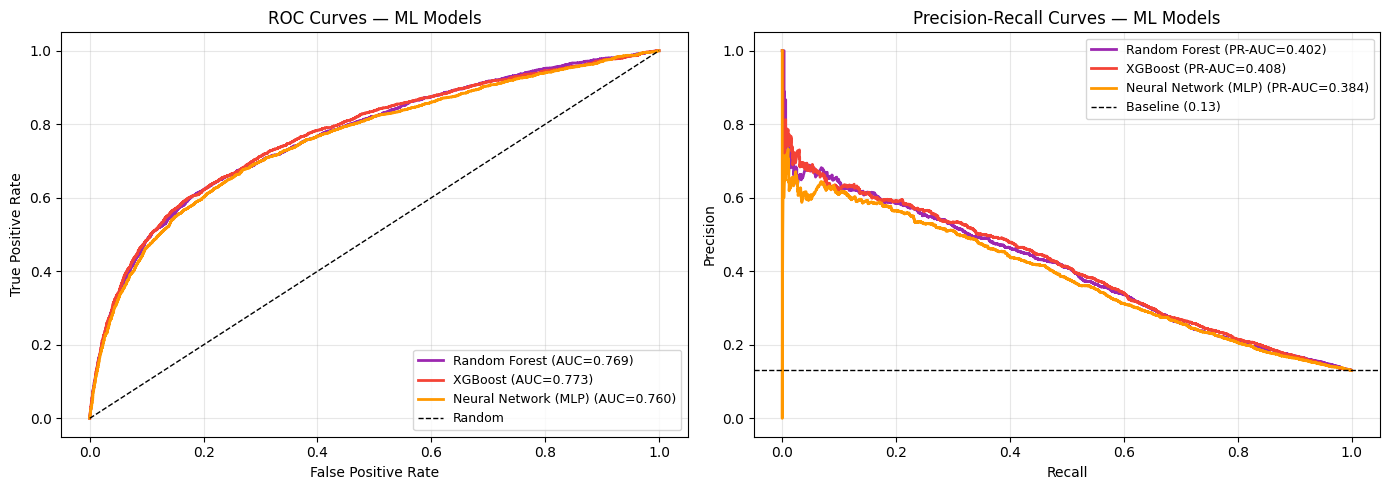

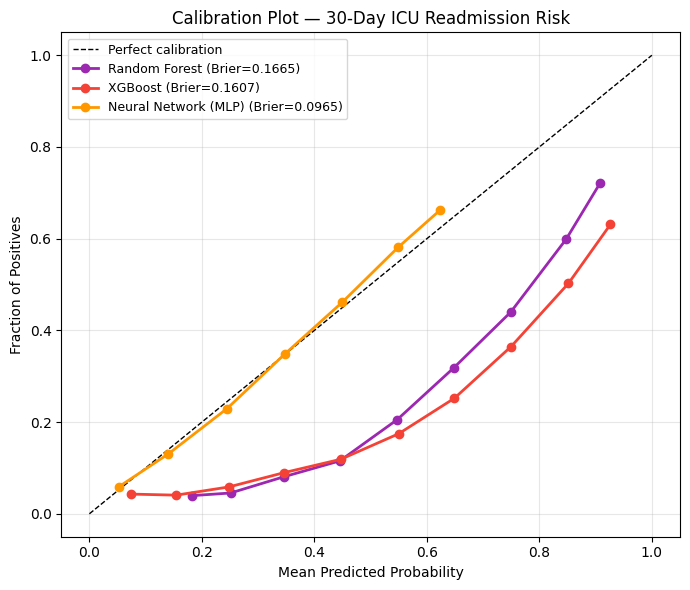

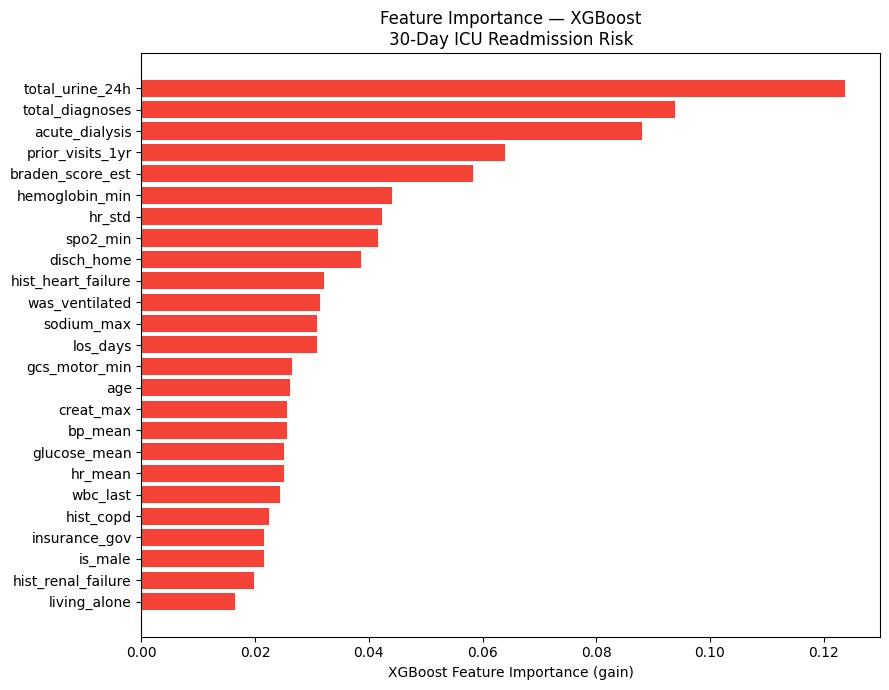

Model                        AUC   PR-AUC     F1   Brier   Sens   Spec
Random Forest              0.769    0.402  0.434  0.1665  0.578  0.837
XGBoost                    0.773    0.408  0.430  0.1607  0.605  0.819
Neural Network (MLP)       0.760    0.384  0.239  0.0965  0.150  0.985


In [5]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    brier_score_loss, confusion_matrix, roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

PATH       = '/content/drive/MyDrive/seminar/'
INPUT_PATH = PATH + 'mimic_modeling_ready.csv'
SEED       = 42
N_BOOT     = 1000


df = pd.read_csv(INPUT_PATH)

FEATURE_COLS = [
    'age', 'is_male', 'los_days', 'disch_home', 'insurance_gov',
    'living_alone', 'prior_visits_1yr', 'total_diagnoses',
    'hist_heart_failure', 'hist_copd', 'hist_renal_failure',
    'acute_dialysis', 'was_ventilated', 'hr_mean', 'hr_std',
    'bp_mean', 'spo2_min', 'gcs_motor_min', 'braden_score_est',
    'creat_max', 'sodium_max', 'hemoglobin_min', 'glucose_mean',
    'wbc_last', 'total_urine_24h'
]

X      = df[FEATURE_COLS].copy()
y      = df['readmitted_30d'].copy()

train_idx = np.load(PATH + 'train_idx.npy')
test_idx  = np.load(PATH + 'test_idx.npy')

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()

mice   = joblib.load(PATH + 'mice_imputer_phase2.pkl')
scaler = joblib.load(PATH + 'standard_scaler.pkl')

X_train_imp = mice.transform(X_train)
X_test_imp  = mice.transform(X_test)
X_train_sc  = scaler.transform(X_train_imp)
X_test_sc   = scaler.transform(X_test_imp)

print(f"  Train: {len(X_train):,} | Test: {len(X_test):,}")

def evaluate(name, y_true, y_prob, threshold=0.5):
    rng    = np.random.default_rng(SEED)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        "AUC"        : roc_auc_score(y_true, y_prob),
        "PR_AUC"     : average_precision_score(y_true, y_prob),
        "F1"         : f1_score(y_true, y_pred),
        "Brier"      : brier_score_loss(y_true, y_prob),
        "Sensitivity": tp/(tp+fn) if (tp+fn)>0 else 0,
        "Specificity": tn/(tn+fp) if (tn+fp)>0 else 0,
    }

    boot = {k: [] for k in metrics}
    ya, n = np.array(y_true), len(y_true)
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        yb, pb = ya[idx], y_prob[idx]
        yp     = (pb >= threshold).astype(int)
        if len(np.unique(yb)) < 2:
            continue
        tni,fpi,fni,tpi = confusion_matrix(yb,yp).ravel()
        boot["AUC"].append(roc_auc_score(yb, pb))
        boot["PR_AUC"].append(average_precision_score(yb, pb))
        boot["F1"].append(f1_score(yb, yp, zero_division=0))
        boot["Brier"].append(brier_score_loss(yb, pb))
        boot["Sensitivity"].append(tpi/(tpi+fni) if (tpi+fni)>0 else 0)
        boot["Specificity"].append(tni/(tni+fpi) if (tni+fpi)>0 else 0)

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    for k, v in metrics.items():
        lo = np.percentile(boot[k], 2.5)
        hi = np.percentile(boot[k], 97.5)
        print(f"  {k:<15} {v:.4f}   [{lo:.4f}, {hi:.4f}]")

    return metrics

all_probs   = {}
all_metrics = {}

rf = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = 10,
    min_samples_leaf= 20,
    max_features    = 'sqrt',
    class_weight    = 'balanced',
    n_jobs          = -1,
    random_state    = SEED,
)
rf.fit(X_train_sc, y_train)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

m = evaluate("Random Forest", y_test, y_prob_rf)
all_probs["Random Forest"]   = y_prob_rf
all_metrics["Random Forest"] = m
joblib.dump(rf, PATH + 'model_rf.pkl')

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos, 1)
print(f"  scale_pos_weight = {spw} (neg/pos ratio)")

xgb = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = spw,
    eval_metric      = 'auc',
    random_state     = SEED,
    n_jobs           = -1,
    verbosity        = 0,
)
xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=50
)
y_prob_xgb = xgb.predict_proba(X_test_sc)[:, 1]

m = evaluate("XGBoost", y_test, y_prob_xgb)
all_probs["XGBoost"]   = y_prob_xgb
all_metrics["XGBoost"] = m
joblib.dump(xgb, PATH + 'model_xgb.pkl')

mlp = MLPClassifier(
    hidden_layer_sizes = (128, 64, 32),
    activation         = 'relu',
    max_iter           = 50,
    batch_size         = 256,
    learning_rate_init = 0.001,
    early_stopping     = True,
    n_iter_no_change   = 5,
    random_state       = SEED,
    verbose            = False,
)
mlp.fit(X_train_sc, y_train)
y_prob_mlp = mlp.predict_proba(X_test_sc)[:, 1]

m = evaluate("Neural Network (MLP)", y_test, y_prob_mlp)
all_probs["Neural Network (MLP)"]   = y_prob_mlp
all_metrics["Neural Network (MLP)"] = m
joblib.dump(mlp, PATH + 'model_mlp.pkl')

preds_df = pd.DataFrame({
    "y_true"  : y_test.values,
    "prob_rf" : y_prob_rf,
    "prob_xgb": y_prob_xgb,
    "prob_mlp": y_prob_mlp,
})
preds_df.to_csv(PATH + 'phase3_test_predictions.csv', index=False)

with open(PATH + 'metrics_ml.json', 'w') as f:
    json.dump({n:{k:round(v,4) for k,v in m.items()}
               for n,m in all_metrics.items()}, f, indent=2)

colors = {
    "Random Forest"       : "#9C27B0",
    "XGBoost"             : "#F44336",
    "Neural Network (MLP)": "#FF9800"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, y_prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors[name], lw=2,
            label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],"k--", lw=1, label="Random")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="ROC Curves — ML Models")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for name, y_prob in all_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=colors[name], lw=2,
            label=f"{name} (PR-AUC={pr_auc:.3f})")
ax.axhline(y_test.mean(), color="k", linestyle="--", lw=1,
           label=f"Baseline ({y_test.mean():.2f})")
ax.set(xlabel="Recall", ylabel="Precision",
       title="Precision-Recall Curves — ML Models")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PATH + 'phase3_roc_pr_curves.png', dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],"k--", lw=1, label="Perfect calibration")
for name, y_prob in all_probs.items():
    pt, pp = calibration_curve(y_test, y_prob, n_bins=10)
    brier  = brier_score_loss(y_test, y_prob)
    ax.plot(pp, pt, marker="o", color=colors[name], lw=2,
            label=f"{name} (Brier={brier:.4f})")
ax.set(xlabel="Mean Predicted Probability",
       ylabel="Fraction of Positives",
       title="Calibration Plot — 30-Day ICU Readmission Risk")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PATH + 'phase3_calibration.png', dpi=150, bbox_inches="tight")
plt.show()

feat_imp = pd.DataFrame({
    "feature"   : FEATURE_COLS,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feat_imp["feature"], feat_imp["importance"], color="#F44336")
ax.set(xlabel="XGBoost Feature Importance (gain)",
       title="Feature Importance — XGBoost\n30-Day ICU Readmission Risk")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(PATH + 'phase3_xgb_features.png', dpi=150, bbox_inches="tight")
plt.show()

print(f"{'Model':<25} {'AUC':>6} {'PR-AUC':>8} {'F1':>6} {'Brier':>7} {'Sens':>6} {'Spec':>6}")

for name, m in all_metrics.items():
    print(f"{name:<25} {m['AUC']:>6.3f} {m['PR_AUC']:>8.3f} "
          f"{m['F1']:>6.3f} {m['Brier']:>7.4f} "
          f"{m['Sensitivity']:>6.3f} {m['Specificity']:>6.3f}")


  Test set: 16,499 stays

Computing SHAP values (n=500 samples)...
  SHAP shape: (500, 25)


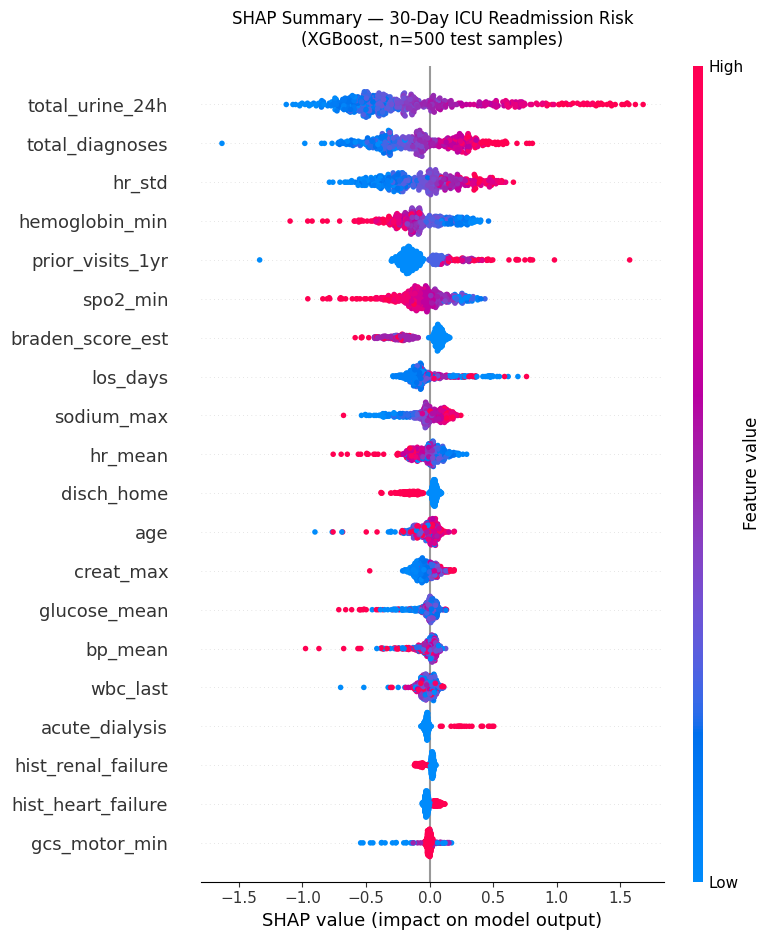

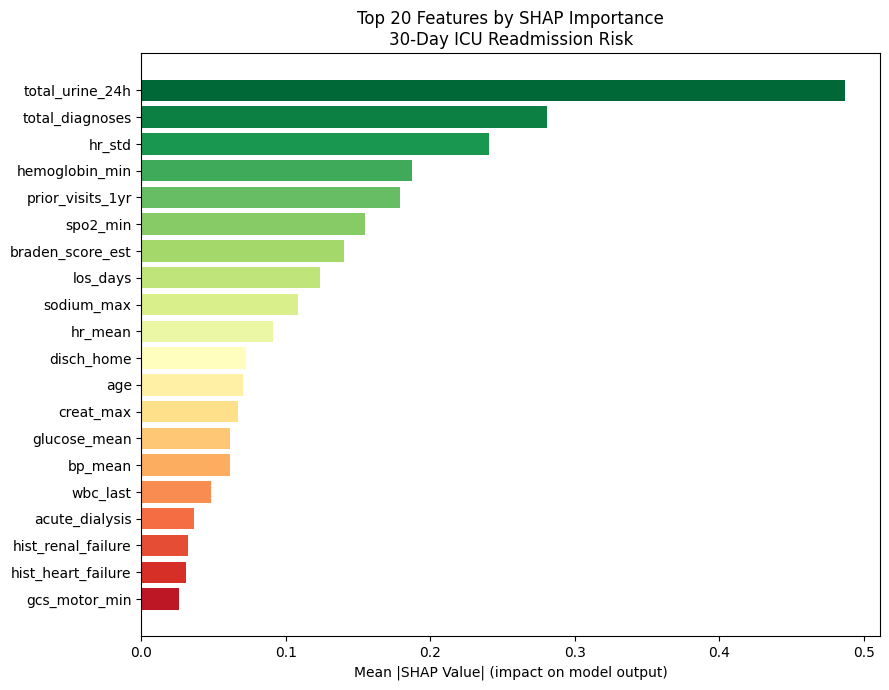

  Saved shap_bar_plot.png
         feature  mean_shap
 total_urine_24h   0.486954
 total_diagnoses   0.280784
          hr_std   0.240934
  hemoglobin_min   0.187346
prior_visits_1yr   0.179063
        spo2_min   0.154514
braden_score_est   0.139959
        los_days   0.123864
      sodium_max   0.108687
         hr_mean   0.090747


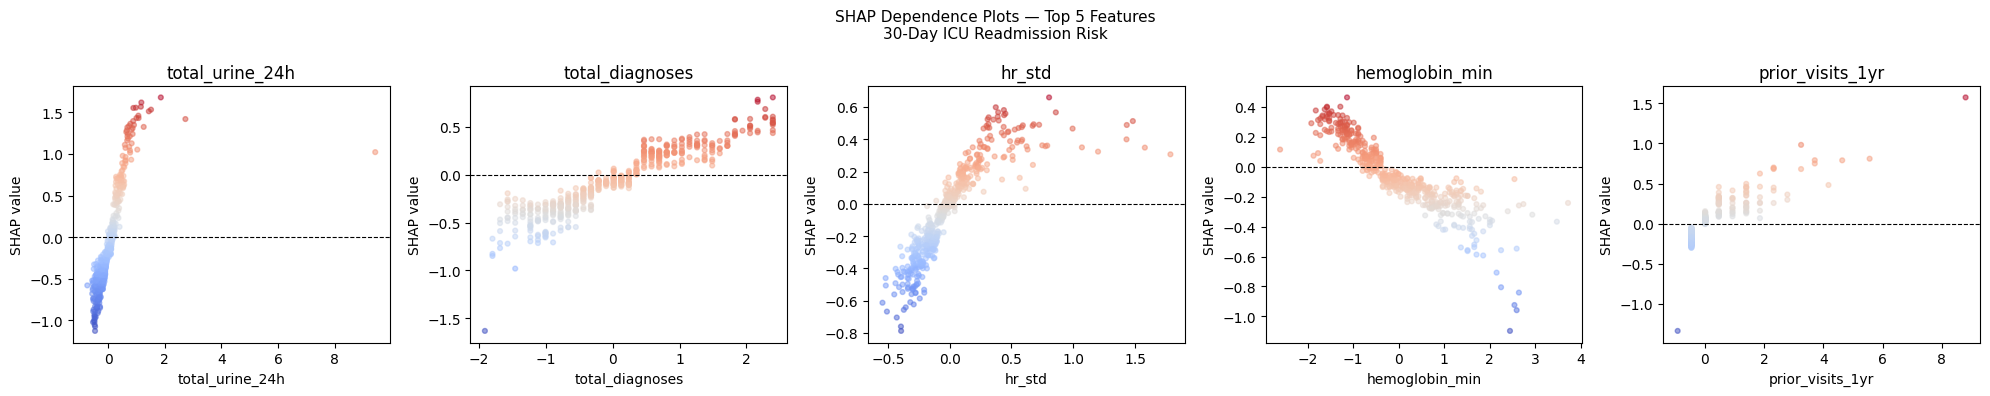

  Computing Logistic Regression...
  Computing LASSO (L1)...
  Computing Ridge (L2)...
  Computing Random Forest...
  Computing XGBoost...
  Computing Neural Network (MLP)...


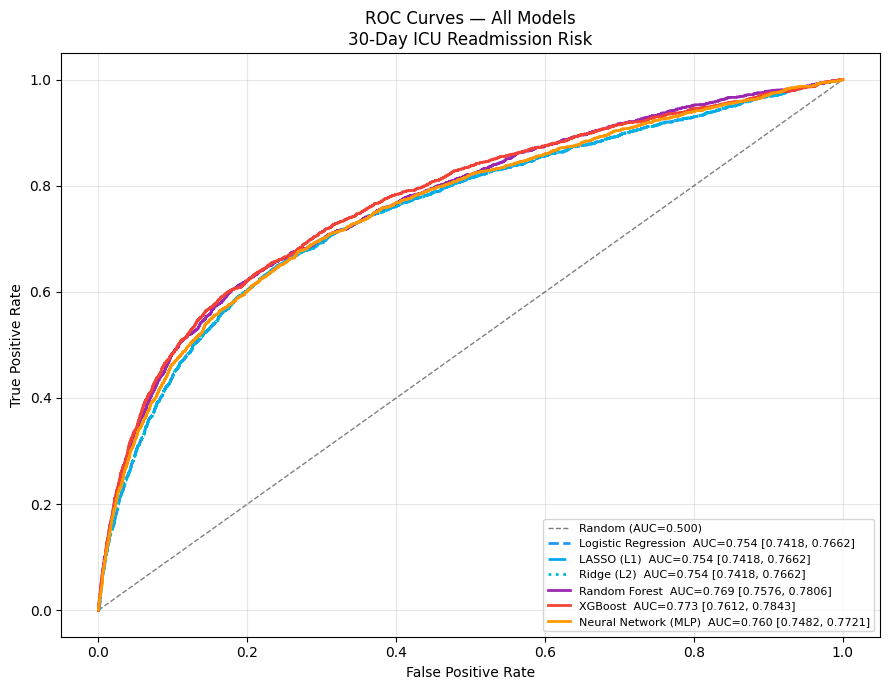

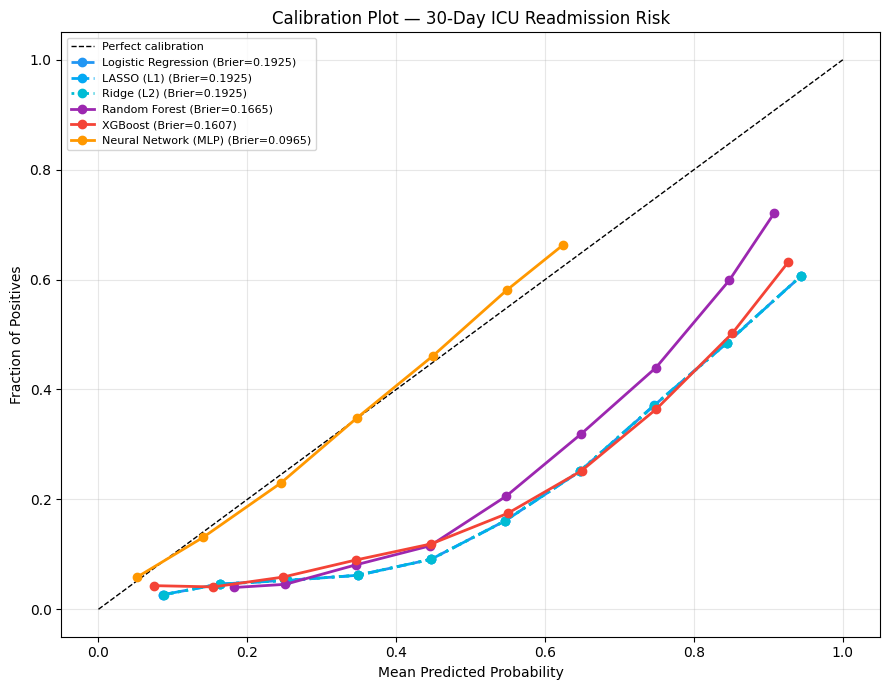

               Model    AUC           AUC_CI  PR_AUC     F1  Brier  Sensitivity  Specificity
 Logistic Regression 0.7538 [0.7418, 0.7662]  0.3673 0.3948 0.1925       0.6565       0.7493
          LASSO (L1) 0.7538 [0.7418, 0.7662]  0.3673 0.3948 0.1925       0.6565       0.7494
          Ridge (L2) 0.7538 [0.7418, 0.7662]  0.3673 0.3950 0.1925       0.6565       0.7496
       Random Forest 0.7693 [0.7576, 0.7806]  0.4020 0.4341 0.1665       0.5785       0.8369
             XGBoost 0.7730 [0.7612, 0.7843]  0.4077 0.4304 0.1607       0.6049       0.8189
Neural Network (MLP) 0.7601 [0.7482, 0.7721]  0.3839 0.2393 0.0965       0.1500       0.9845

  Best model : XGBoost
  AUC        : 0.773  [0.7612, 0.7843]
  Brier      : 0.1607
  F1         : 0.4304


In [6]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    brier_score_loss, confusion_matrix, roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve

PATH       = '/content/drive/MyDrive/seminar/'
INPUT_PATH = PATH + 'mimic_modeling_ready.csv'
SEED       = 42
N_BOOT     = 1000
N_SAMPLES  = 500   

FEATURE_COLS = [
    'age', 'is_male', 'los_days', 'disch_home', 'insurance_gov',
    'living_alone', 'prior_visits_1yr', 'total_diagnoses',
    'hist_heart_failure', 'hist_copd', 'hist_renal_failure',
    'acute_dialysis', 'was_ventilated', 'hr_mean', 'hr_std',
    'bp_mean', 'spo2_min', 'gcs_motor_min', 'braden_score_est',
    'creat_max', 'sodium_max', 'hemoglobin_min', 'glucose_mean',
    'wbc_last', 'total_urine_24h'
]

df       = pd.read_csv(INPUT_PATH)
X        = df[FEATURE_COLS].copy()
y        = df['readmitted_30d'].copy()

test_idx  = np.load(PATH + 'test_idx.npy')
train_idx = np.load(PATH + 'train_idx.npy')

X_test  = X.iloc[test_idx].copy()
y_test  = y.iloc[test_idx].copy()

mice   = joblib.load(PATH + 'mice_imputer_phase2.pkl')
scaler = joblib.load(PATH + 'standard_scaler.pkl')

X_test_sc = scaler.transform(mice.transform(X_test))
X_test_df = pd.DataFrame(X_test_sc, columns=FEATURE_COLS)

print(f"  Test set: {len(X_test):,} stays")

xgb = joblib.load(PATH + 'model_xgb.pkl')

print(f"\nComputing SHAP values (n={N_SAMPLES} samples)...")

rng        = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_test_df), size=N_SAMPLES, replace=False)
X_shap     = X_test_df.iloc[sample_idx]

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"  SHAP shape: {shap_values.shape}")


plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title(
    "SHAP Summary — 30-Day ICU Readmission Risk\n"
    f"(XGBoost, n={N_SAMPLES} test samples)",
    fontsize=12, pad=15
)
plt.tight_layout()
plt.savefig(PATH + 'shap_summary_plot.png', dpi=150, bbox_inches="tight")
plt.show()
plt.close()

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({
    "feature"   : FEATURE_COLS,
    "mean_shap" : mean_shap
}).sort_values("mean_shap", ascending=False).head(20)

cmap   = plt.cm.RdYlGn_r
colors = [cmap(i/len(shap_df)) for i in range(len(shap_df))]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_df["feature"], shap_df["mean_shap"], color=colors)
ax.set(xlabel="Mean |SHAP Value| (impact on model output)",
       title="Top 20 Features by SHAP Importance\n30-Day ICU Readmission Risk")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(PATH + 'shap_bar_plot.png', dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  Saved shap_bar_plot.png")

# Print top 10

print(shap_df.head(10).to_string(index=False))

top5 = shap_df["feature"].head(5).tolist()
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top5):
    feat_idx = FEATURE_COLS.index(feat)
    sc = ax.scatter(
        X_shap[feat], shap_values[:, feat_idx],
        c=shap_values[:, feat_idx],
        cmap="coolwarm", alpha=0.5, s=12
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set(xlabel=feat, ylabel="SHAP value", title=feat)

plt.suptitle(
    "SHAP Dependence Plots — Top 5 Features\n30-Day ICU Readmission Risk",
    fontsize=11
)
plt.tight_layout()
plt.savefig(PATH + 'shap_dependence_plots.png', dpi=150, bbox_inches="tight")
plt.show()
plt.close()

shap_out = pd.DataFrame(shap_values, columns=FEATURE_COLS)
shap_out.insert(0, "y_true", y_test.iloc[sample_idx].values)
shap_out.to_csv(PATH + 'shap_values.csv', index=False)

p2 = pd.read_csv(PATH + 'phase2_test_predictions.csv')
p3 = pd.read_csv(PATH + 'phase3_test_predictions.csv')

assert np.array_equal(p2["y_true"].values, p3["y_true"].values), \
    "Test sets differ — recheck split!"


y_true = p2["y_true"].values

all_probs = {
    "Logistic Regression" : p2["prob_lr"].values,
    "LASSO (L1)"          : p2["prob_lasso"].values,
    "Ridge (L2)"          : p2["prob_ridge"].values,
    "Random Forest"       : p3["prob_rf"].values,
    "XGBoost"             : p3["prob_xgb"].values,
    "Neural Network (MLP)": p3["prob_mlp"].values,
}

def full_evaluate(name, y_true, y_prob, threshold=0.5):
    rng    = np.random.default_rng(SEED)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    point = {
        "AUC"        : roc_auc_score(y_true, y_prob),
        "PR_AUC"     : average_precision_score(y_true, y_prob),
        "F1"         : f1_score(y_true, y_pred),
        "Brier"      : brier_score_loss(y_true, y_prob),
        "Sensitivity": tp/(tp+fn) if (tp+fn)>0 else 0,
        "Specificity": tn/(tn+fp) if (tn+fp)>0 else 0,
    }

    boot = {k: [] for k in point}
    n    = len(y_true)
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        yb, pb = y_true[idx], y_prob[idx]
        yp     = (pb >= threshold).astype(int)
        if len(np.unique(yb)) < 2:
            continue
        tni,fpi,fni,tpi = confusion_matrix(yb,yp).ravel()
        boot["AUC"].append(roc_auc_score(yb, pb))
        boot["PR_AUC"].append(average_precision_score(yb, pb))
        boot["F1"].append(f1_score(yb, yp, zero_division=0))
        boot["Brier"].append(brier_score_loss(yb, pb))
        boot["Sensitivity"].append(tpi/(tpi+fni) if (tpi+fni)>0 else 0)
        boot["Specificity"].append(tni/(tni+fpi) if (tni+fpi)>0 else 0)

    row = {"Model": name}
    for k, v in point.items():
        lo = np.percentile(boot[k], 2.5)
        hi = np.percentile(boot[k], 97.5)
        row[k]         = round(v, 4)
        row[f"{k}_CI"] = f"[{lo:.4f}, {hi:.4f}]"
    return row

rows = []
for name, y_prob in all_probs.items():
    print(f"  Computing {name}...")
    rows.append(full_evaluate(name, y_true, y_prob))

results_df = pd.DataFrame(rows)
results_df.to_csv(PATH + 'final_results_table.csv', index=False)

metrics_json = {
    row["Model"]: {k: row[k] for k in
                   ["AUC","AUC_CI","PR_AUC","F1","Brier","Sensitivity","Specificity"]}
    for _, row in results_df.iterrows()
}
with open(PATH + 'final_metrics.json', 'w') as f:
    json.dump(metrics_json, f, indent=2)


colors = {
    "Logistic Regression" :"#2196F3", "LASSO (L1)"          :"#03A9F4",
    "Ridge (L2)"          :"#00BCD4", "Random Forest"        :"#9C27B0",
    "XGBoost"             :"#F44336", "Neural Network (MLP)" :"#FF9800",
}
styles = {
    "Logistic Regression":"--","LASSO (L1)":"-.","Ridge (L2)"       :":",
    "Random Forest"      :"-" ,"XGBoost"   :"-","Neural Network (MLP)":"-",
}

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0,1],[0,1],"k--", lw=1, alpha=0.5, label="Random (AUC=0.500)")
for name, y_prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ci  = results_df[results_df.Model==name]["AUC_CI"].values[0]
    ax.plot(fpr, tpr, color=colors[name], linestyle=styles[name], lw=2,
            label=f"{name}  AUC={auc:.3f} {ci}")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="ROC Curves — All Models\n30-Day ICU Readmission Risk")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PATH + 'final_roc_plot.png', dpi=150, bbox_inches="tight")
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0,1],[0,1],"k--", lw=1, label="Perfect calibration")
for name, y_prob in all_probs.items():
    pt, pp = calibration_curve(y_true, y_prob, n_bins=10)
    brier  = brier_score_loss(y_true, y_prob)
    ax.plot(pp, pt, marker="o", color=colors[name], linestyle=styles[name], lw=2,
            label=f"{name} (Brier={brier:.4f})")
ax.set(xlabel="Mean Predicted Probability",
       ylabel="Fraction of Positives",
       title="Calibration Plot — 30-Day ICU Readmission Risk")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PATH + 'final_calibration_plot.png', dpi=150, bbox_inches="tight")
plt.show()
plt.close()

disp = ["Model","AUC","AUC_CI","PR_AUC","F1","Brier","Sensitivity","Specificity"]
print(results_df[disp].to_string(index=False))

best = results_df.loc[results_df["AUC"].idxmax()]
print(f"\n  Best model : {best['Model']}")
print(f"  AUC        : {best['AUC']}  {best['AUC_CI']}")
print(f"  Brier      : {best['Brier']}")
print(f"  F1         : {best['F1']}")

